# IT4060 - HPC Failure Prediction

## Notebook: Random Forest

This notebook trains a random forest model using the processed multi-horizon feature table. The default target is `label_next_6h`, and the evaluation structure matches the logistic-regression baseline so later model comparison stays consistent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
PROJECT_NAME = 'IT4060-ML-Assignment-HPC-Failure-Prediction'
TARGET_COLUMN = 'label_next_6h'
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
N_ESTIMATORS = 100
MAX_DEPTH = 14
MIN_SAMPLES_LEAF = 5
MAX_SAMPLES = 0.20
N_JOBS = 1
MODEL_VERBOSE = 1
RESULTS_MODEL_NAME = 'random_forest'

def find_project_root():
    cwd = Path.cwd().resolve()
    home = Path.home().resolve()
    desktop = home / 'Desktop'
    candidate_roots = [cwd, *cwd.parents, home, desktop, desktop / 'Manilka' / 'ML_Assignment']
    seen = set()

    for base in candidate_roots:
        for candidate in (base, base / PROJECT_NAME):
            if candidate in seen or not candidate.exists():
                continue
            seen.add(candidate)
            if (candidate / 'data' / 'processed').exists():
                return candidate

    raise FileNotFoundError('Could not locate the project root with data/processed.')

project_root = find_project_root()
processed_dir = project_root / 'data' / 'processed'
processed_path = processed_dir / 'node_hour_features_multi_horizon.csv.gz'
results_dir = project_root / 'results'
model_results_dir = results_dir / RESULTS_MODEL_NAME

if not processed_path.exists():
    raise FileNotFoundError('Processed feature table not found. Run 03_feature_engineering.ipynb first.')

model_results_dir.mkdir(parents=True, exist_ok=True)
overview_path = model_results_dir / 'overview.csv'
split_summary_path = model_results_dir / 'split_summary.csv'
run_metadata_path = model_results_dir / 'run_metadata.csv'
validation_metrics_path = model_results_dir / 'validation_metrics.csv'
validation_curve_path = model_results_dir / 'validation_threshold_curve.csv'
test_metrics_path = model_results_dir / 'test_metrics.csv'
test_risk_scores_path = model_results_dir / 'test_risk_scores.csv.gz'
top_risk_rows_path = model_results_dir / 'top_risk_rows.csv'
split_plot_path = model_results_dir / 'split_overview.png'
validation_plot_path = model_results_dir / 'validation_diagnostics.png'
test_plot_path = model_results_dir / 'test_evaluation.png'
feature_importance_path = model_results_dir / 'feature_importance.csv'
feature_importance_plot_path = model_results_dir / 'feature_importance.png'

print(f'Working directory: {Path.cwd()}')
print(f'Project root: {project_root}')
print(f'Processed data path: {processed_path}')
print(f'Results directory: {model_results_dir}')
print(f'Target column: {TARGET_COLUMN}')
print(f'Number of trees: {N_ESTIMATORS}')
print(f'Max depth: {MAX_DEPTH}')
print(f'Min samples leaf: {MIN_SAMPLES_LEAF}')
print(f'Max samples: {MAX_SAMPLES}')
print(f'Model verbose: {MODEL_VERBOSE}')


Working directory: c:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\notebooks
Project root: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction
Processed data path: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\data\processed\node_hour_features_multi_horizon.csv.gz
Results directory: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\results\random_forest
Target column: label_next_6h
Number of trees: 100
Max depth: 14
Min samples leaf: 5
Max samples: 0.2
Model verbose: 1


In [3]:
df = pd.read_csv(
    processed_path,
    parse_dates=['hour', 'next_failure_time'],
    low_memory=False,
)

target_columns = [column for column in df.columns if column.startswith('label_next_')]
feature_exclusions = ['hour', 'next_failure_time', 'hours_to_next_failure', *target_columns]
feature_columns = [column for column in df.columns if column not in feature_exclusions]

overview = pd.DataFrame([
    {'metric': 'Rows', 'value': len(df)},
    {'metric': 'Feature columns', 'value': len(feature_columns)},
    {'metric': 'Target positive count', 'value': int(df[TARGET_COLUMN].sum())},
    {'metric': 'Target positive rate', 'value': float(df[TARGET_COLUMN].mean())},
    {'metric': 'Hour range start', 'value': df['hour'].min()},
    {'metric': 'Hour range end', 'value': df['hour'].max()},
])

overview.to_csv(overview_path, index=False)

display(overview)
display(df[['node', 'hour', 'label_next_1h', 'label_next_6h', 'label_next_12h', 'label_next_24h']].head())

,metric,value
0,Rows,687814
1,Feature columns,34
2,Target positive count,701
3,Target positive rate,0.001019
4,Hour range start,2003-12-26 12:00:00
5,Hour range end,2005-10-21 20:00:00


,node,hour,label_next_1h,label_next_6h,label_next_12h,label_next_24h
0,0,2003-12-26 13:00:00,0,0,0,0
1,0,2003-12-26 14:00:00,0,0,0,0
2,0,2003-12-26 15:00:00,0,0,0,0
3,0,2003-12-26 19:00:00,0,0,0,0
4,0,2003-12-27 00:00:00,0,0,0,0


In [4]:
unique_hours = np.sort(df['hour'].unique())
train_end = int(len(unique_hours) * TRAIN_RATIO)
valid_end = int(len(unique_hours) * (TRAIN_RATIO + VALID_RATIO))

train_hours = unique_hours[:train_end]
valid_hours = unique_hours[train_end:valid_end]
test_hours = unique_hours[valid_end:]

train_df = df[df['hour'].isin(train_hours)].copy()
valid_df = df[df['hour'].isin(valid_hours)].copy()
test_df = df[df['hour'].isin(test_hours)].copy()

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'rows': len(train_df),
        'positives': int(train_df[TARGET_COLUMN].sum()),
        'positive_rate': float(train_df[TARGET_COLUMN].mean()),
        'start_hour': train_df['hour'].min(),
        'end_hour': train_df['hour'].max(),
    },
    {
        'split': 'validation',
        'rows': len(valid_df),
        'positives': int(valid_df[TARGET_COLUMN].sum()),
        'positive_rate': float(valid_df[TARGET_COLUMN].mean()),
        'start_hour': valid_df['hour'].min(),
        'end_hour': valid_df['hour'].max(),
    },
    {
        'split': 'test',
        'rows': len(test_df),
        'positives': int(test_df[TARGET_COLUMN].sum()),
        'positive_rate': float(test_df[TARGET_COLUMN].mean()),
        'start_hour': test_df['hour'].min(),
        'end_hour': test_df['hour'].max(),
    },
])

split_summary.to_csv(split_summary_path, index=False)

display(split_summary)

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]
X_valid = valid_df[feature_columns]
y_valid = valid_df[TARGET_COLUMN]
X_test = test_df[feature_columns]
y_test = test_df[TARGET_COLUMN]

,split,rows,positives,positive_rate,start_hour,end_hour
0,train,488782,577,0.001180,2003-12-26 12:00:00,2005-04-08 16:00:00
1,validation,114395,76,0.000664,2005-04-08 17:00:00,2005-07-16 21:00:00
2,test,84637,48,0.000567,2005-07-16 22:00:00,2005-10-21 20:00:00


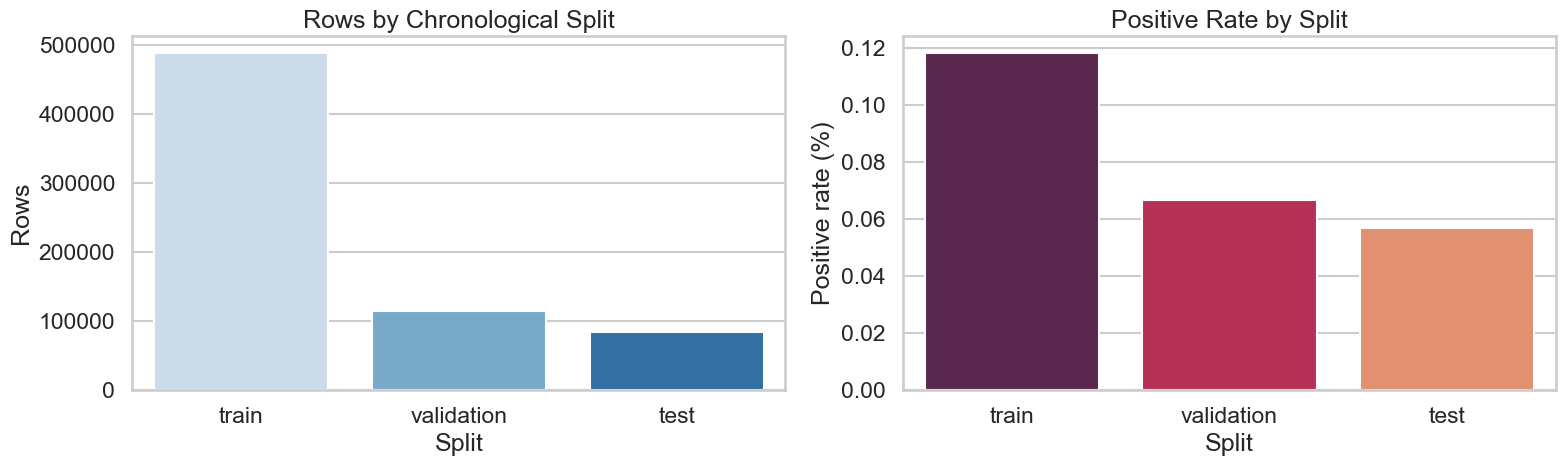

In [5]:
split_plot_df = split_summary.copy()
split_plot_df['positive_rate_percent'] = split_plot_df['positive_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=split_plot_df, x='split', y='rows', hue='split', dodge=False, legend=False, ax=axes[0], palette='Blues')
axes[0].set_title('Rows by Chronological Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Rows')

sns.barplot(data=split_plot_df, x='split', y='positive_rate_percent', hue='split', dodge=False, legend=False, ax=axes[1], palette='rocket')
axes[1].set_title('Positive Rate by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Positive rate (%)')

plt.tight_layout()
fig.savefig(split_plot_path, bbox_inches='tight')
plt.show()

In [6]:
categorical_features = ['node']
numeric_features = [column for column in feature_columns if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore', sparse_output=True),
            categorical_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                ]
            ),
            numeric_features,
        ),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestClassifier(
                n_estimators=N_ESTIMATORS,
                max_depth=MAX_DEPTH,
                min_samples_leaf=MIN_SAMPLES_LEAF,
                max_samples=MAX_SAMPLES,
                class_weight='balanced_subsample',
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
                verbose=MODEL_VERBOSE,
            ),
        ),
    ]
)

model_pipeline.fit(X_train, y_train)
trained_random_forest = model_pipeline.named_steps['model']
fitted_preprocessor = model_pipeline.named_steps['preprocessor']
feature_importance = pd.DataFrame({
    'feature': fitted_preprocessor.get_feature_names_out(),
    'importance': trained_random_forest.feature_importances_,
}).sort_values('importance', ascending=False)
feature_importance.to_csv(feature_importance_path, index=False)

print('Random forest fitted successfully.')
print(f'Trees trained: {trained_random_forest.n_estimators}')
print(f'Feature count after preprocessing: {len(feature_importance)}')

run_metadata = pd.DataFrame([
    {
        'model_name': RESULTS_MODEL_NAME,
        'target_column': TARGET_COLUMN,
        'n_estimators': N_ESTIMATORS,
        'max_depth': MAX_DEPTH,
        'min_samples_leaf': MIN_SAMPLES_LEAF,
        'max_samples': MAX_SAMPLES,
        'n_jobs': N_JOBS,
        'train_rows': len(train_df),
        'validation_rows': len(valid_df),
        'test_rows': len(test_df),
        'train_positive_rate': float(y_train.mean()),
        'validation_positive_rate': float(y_valid.mean()),
        'test_positive_rate': float(y_test.mean()),
    }
])
run_metadata.to_csv(run_metadata_path, index=False)

display(feature_importance.head(15))


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min


Random forest fitted successfully.
Trees trained: 100
Feature count after preprocessing: 289


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  2.1min finished


,feature,importance
285,numeric__avg_queue_wait_seconds_rolling_6h,0.059753
283,numeric__total_cpu_time_rolling_6h,0.055263
265,numeric__avg_queue_wait_seconds,0.050536
284,numeric__avg_queue_wait_seconds_lag_1h,0.050142
267,numeric__avg_cpu_user_ratio,0.048348
261,numeric__avg_cpu_time_per_proc,0.046136
266,numeric__median_queue_wait_seconds,0.045976
286,numeric__cpu_time_share_system,0.045771
259,numeric__total_cpu_system_time,0.044350
276,numeric__dominant_hour_of_day,0.043146


In [7]:
def precision_at_k(y_true, scores, k=50):
    if len(scores) == 0:
        return np.nan
    k = min(k, len(scores))
    top_indices = np.argsort(scores)[::-1][:k]
    return float(np.asarray(y_true)[top_indices].mean())

def evaluate_scores(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)
    return {
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'predicted_positives': int(predictions.sum()),
        'precision_at_50': precision_at_k(y_true, scores, k=50),
    }

valid_scores = model_pipeline.predict_proba(X_valid)[:, 1]
precision_curve, recall_curve, threshold_curve = precision_recall_curve(y_valid, valid_scores)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(precision_curve[:-1] + recall_curve[:-1], 1e-12, None)
best_threshold = float(threshold_curve[np.nanargmax(f1_curve)]) if len(threshold_curve) else 0.5

validation_results = pd.DataFrame([
    {'threshold': 0.50, **evaluate_scores(y_valid, valid_scores, 0.50)},
    {'threshold': best_threshold, **evaluate_scores(y_valid, valid_scores, best_threshold)},
])

validation_results.to_csv(validation_metrics_path, index=False)

display(validation_results)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    2.0s finished


,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.500000,0.000808,0.526984,0.000000,0.000000,0.000000,66,0.0
1,0.303499,0.000808,0.526984,0.001726,0.105263,0.003397,4634,0.0


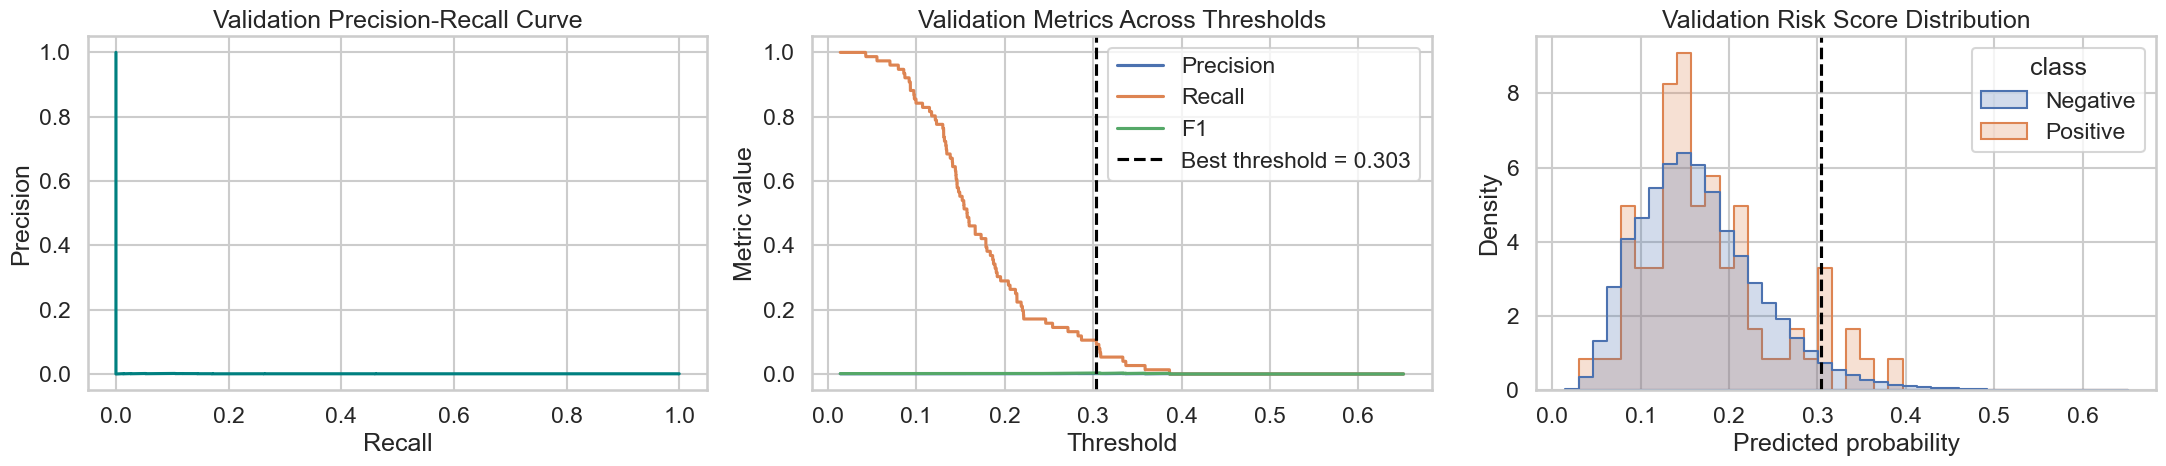

In [8]:
validation_curve_df = pd.DataFrame({
    'threshold': threshold_curve,
    'precision': precision_curve[:-1],
    'recall': recall_curve[:-1],
    'f1': f1_curve,
})

valid_plot_df = pd.DataFrame({
    'score': valid_scores,
    'class': np.where(y_valid.to_numpy() == 1, 'Positive', 'Negative'),
})

validation_curve_df.to_csv(validation_curve_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(recall_curve, precision_curve, color='teal')
axes[0].set_title('Validation Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

axes[1].plot(validation_curve_df['threshold'], validation_curve_df['precision'], label='Precision')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['recall'], label='Recall')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['f1'], label='F1')
axes[1].axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
axes[1].set_title('Validation Metrics Across Thresholds')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Metric value')
axes[1].legend()

sns.histplot(data=valid_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[2])
axes[2].axvline(best_threshold, color='black', linestyle='--')
axes[2].set_title('Validation Risk Score Distribution')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Density')

plt.tight_layout()
fig.savefig(validation_plot_path, bbox_inches='tight')
plt.show()

In [9]:
test_scores = model_pipeline.predict_proba(X_test)[:, 1]
test_results = pd.DataFrame([
    {'threshold': 0.50, **evaluate_scores(y_test, test_scores, 0.50)},
    {'threshold': best_threshold, **evaluate_scores(y_test, test_scores, best_threshold)},
])

test_risk_scores = test_df[['node', 'hour', TARGET_COLUMN]].copy()
test_risk_scores['risk_score'] = test_scores
top_risk_rows = test_risk_scores.sort_values('risk_score', ascending=False).head(20)

test_results.to_csv(test_metrics_path, index=False)
test_risk_scores.to_csv(test_risk_scores_path, index=False, compression='gzip')
top_risk_rows.to_csv(top_risk_rows_path, index=False)

display(test_results)

display(top_risk_rows)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.6s finished


,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.500000,0.000526,0.477452,0.0,0.0,0.0,57,0.0
1,0.303499,0.000526,0.477452,0.0,0.0,0.0,2638,0.0


,node,hour,label_next_6h,risk_score
619198,230,2005-08-09 05:00:00,0,0.620133
6783,0,2005-08-23 07:00:00,0,0.610209
38325,15,2005-08-16 08:00:00,0,0.588808
6410,0,2005-07-20 05:00:00,0,0.585067
6802,0,2005-08-25 14:00:00,0,0.579596
20392,4,2005-08-23 14:00:00,0,0.579222
37127,14,2005-09-20 05:00:00,0,0.572662
6794,0,2005-08-24 16:00:00,0,0.563645
6776,0,2005-08-22 07:00:00,0,0.561298
171312,73,2005-08-24 06:00:00,0,0.559128


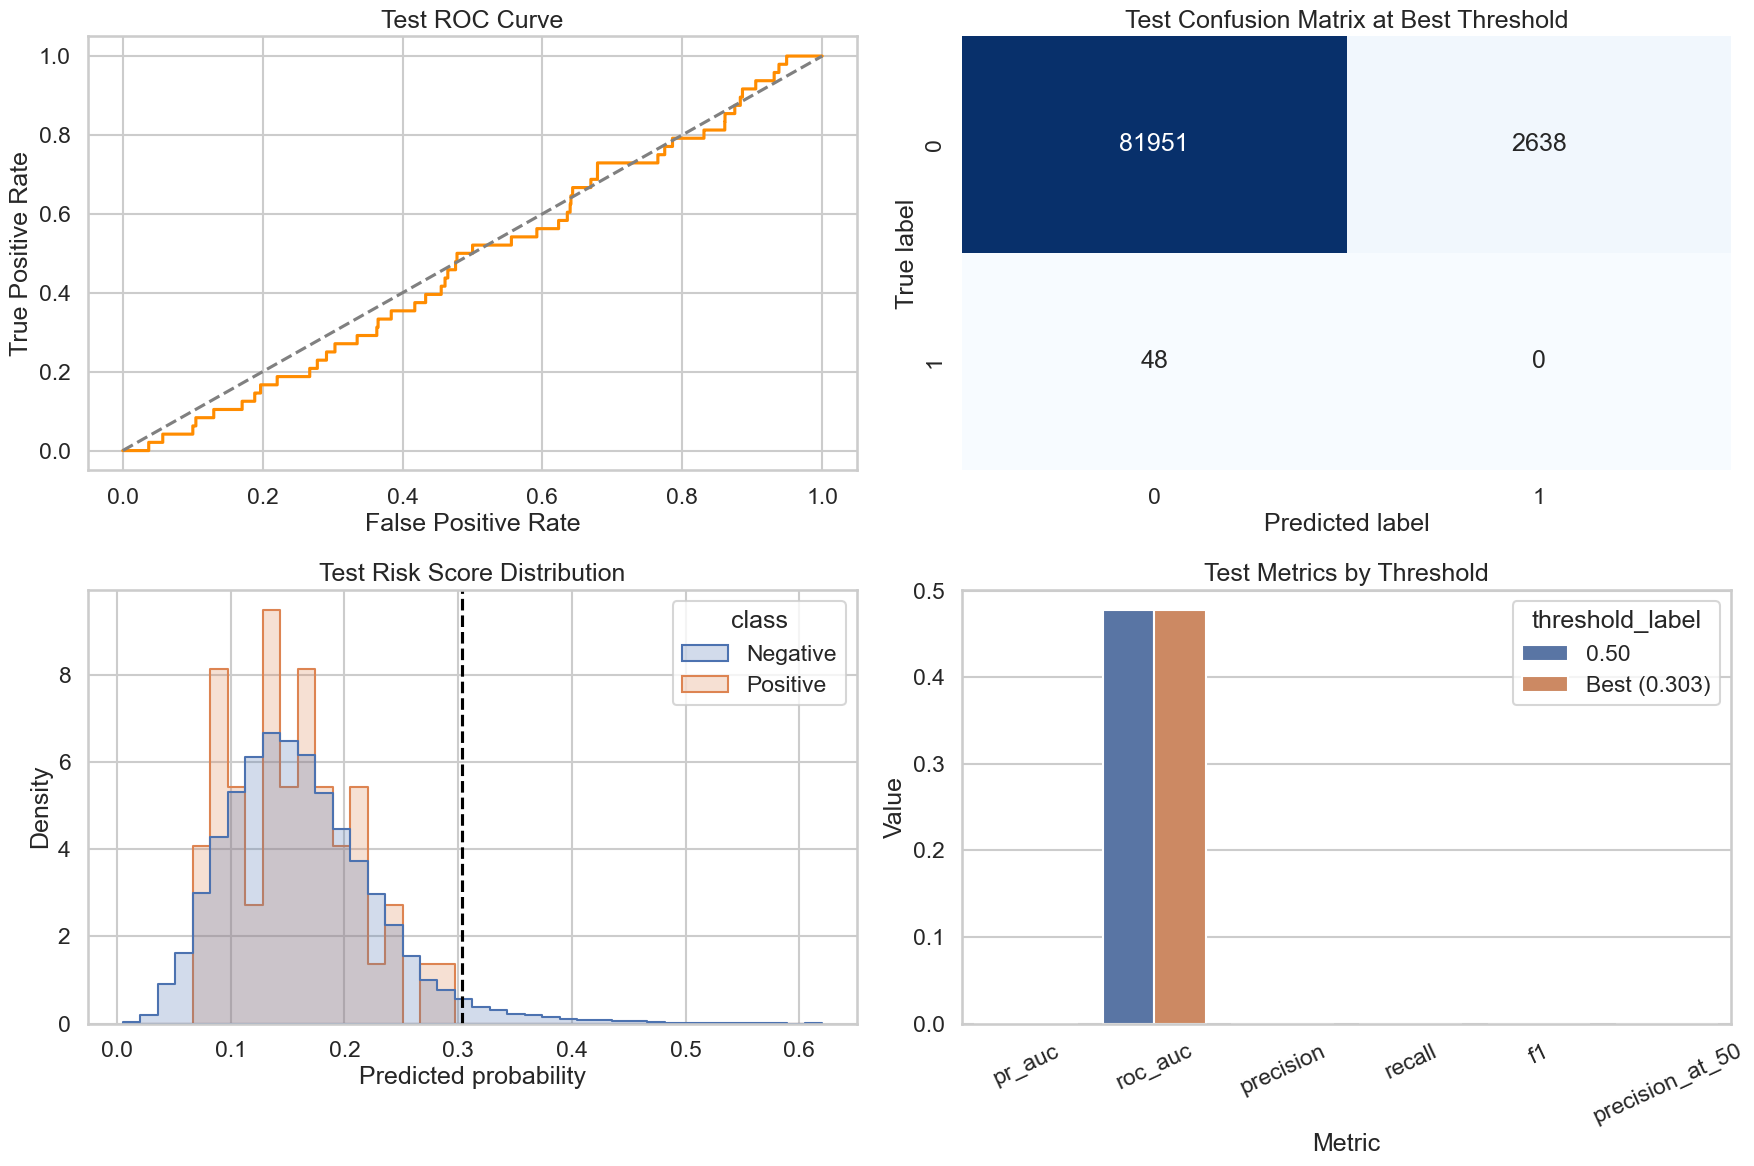

In [10]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
test_predictions_best = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions_best)

test_plot_df = pd.DataFrame({
    'score': test_scores,
    'class': np.where(y_test.to_numpy() == 1, 'Positive', 'Negative'),
})

metrics_plot_df = test_results.melt(
    id_vars='threshold',
    value_vars=['pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'precision_at_50'],
    var_name='metric',
    value_name='value',
)
metrics_plot_df['threshold_label'] = metrics_plot_df['threshold'].map(lambda value: '0.50' if value == 0.5 else f'Best ({value:.3f})')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0, 0].plot(fpr, tpr, color='darkorange')
axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 0].set_title('Test ROC Curve')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 1])
axes[0, 1].set_title('Test Confusion Matrix at Best Threshold')
axes[0, 1].set_xlabel('Predicted label')
axes[0, 1].set_ylabel('True label')

sns.histplot(data=test_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[1, 0])
axes[1, 0].axvline(best_threshold, color='black', linestyle='--')
axes[1, 0].set_title('Test Risk Score Distribution')
axes[1, 0].set_xlabel('Predicted probability')
axes[1, 0].set_ylabel('Density')

sns.barplot(data=metrics_plot_df, x='metric', y='value', hue='threshold_label', ax=axes[1, 1])
axes[1, 1].set_title('Test Metrics by Threshold')
axes[1, 1].set_xlabel('Metric')
axes[1, 1].set_ylabel('Value')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(test_plot_path, bbox_inches='tight')
plt.show()

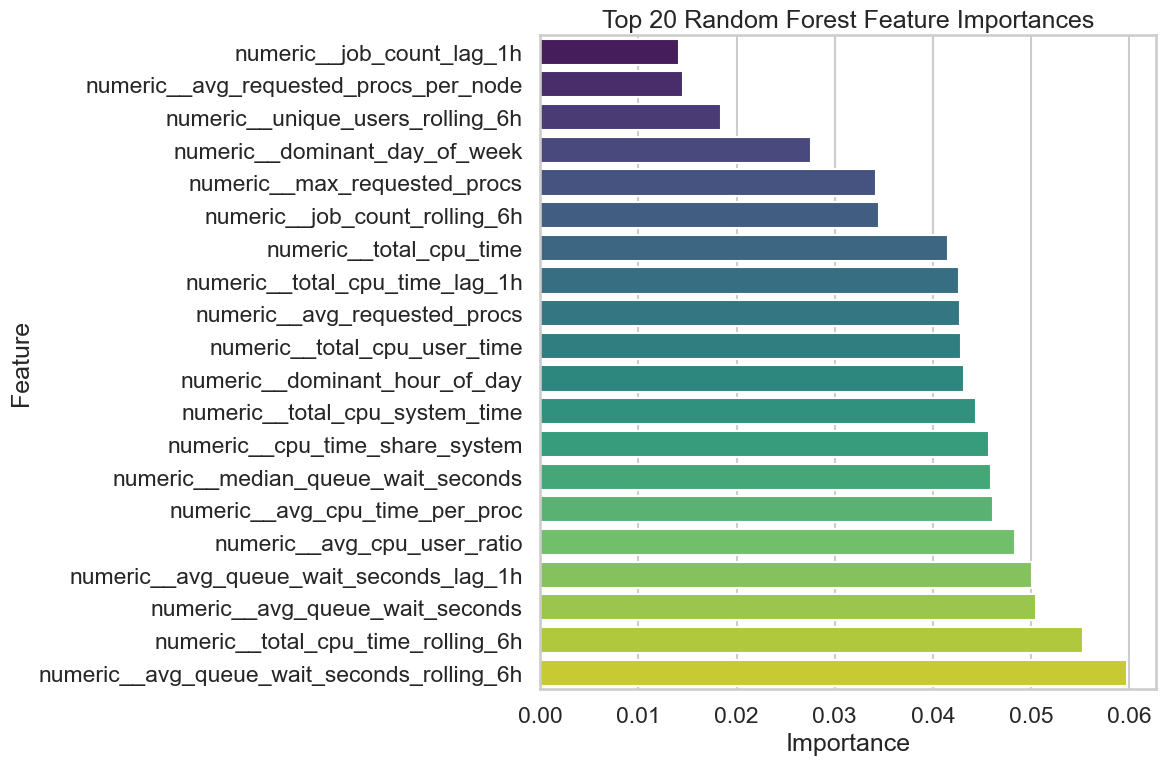

In [11]:
top_feature_importance = feature_importance.head(20).sort_values('importance')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_feature_importance, x='importance', y='feature', hue='feature', dodge=False, legend=False, palette='viridis', ax=ax)
ax.set_title('Top 20 Random Forest Feature Importances')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
fig.savefig(feature_importance_plot_path, bbox_inches='tight')
plt.show()

## Summary

This notebook extends the modeling stage from [04_logistic_regression_baseline.ipynb](04_logistic_regression_baseline.ipynb) by testing a non-linear tree-based model under the same split and evaluation setup. In its current default configuration on `label_next_6h`, the random forest does not outperform the logistic baseline, which suggests that class imbalance and weak predictive signal are still the main bottlenecks rather than model capacity alone.

Saved comparison artifacts for this run are written to `results/random_forest/`, including feature-importance outputs.